# Task 2 — Pipeline & Baseline Experimentation

This notebook runs the complete Task 2 workflow:
1. Load aligned CNBC headlines from Task 1
2. Extract NLP features (TF-IDF intensity + Loughran-McDonald sentiment)
3. Aggregate features to daily level with target variable
4. Add historical rate lag features
5. Chronological train/val/test split
6. Evaluate naive baselines
7. Train combined model (rate lags + NLP features)
8. Compare results

In [1]:
!pip install pysentiment2 scikit-learn pandas numpy matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 32.3 MB/s eta 0:00:00


In [2]:
import ast
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysentiment2 as ps
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

## 1. Load Aligned Headlines

In [4]:
headlines = pd.read_csv('/content/cnbc_headlines_aligned.csv')
headlines['title'] = headlines['title'].astype(str)
headlines['matched_categories'] = headlines['matched_categories'].apply(ast.literal_eval)

print(f'Loaded {len(headlines)} headlines')
print(f'Columns: {list(headlines.columns)}')
headlines.head(3)

Loaded 10997 headlines
Columns: ['article_id', 'title', 'published_at_wib', 'effective_trade_date', 'matched_categories', 'original_url', 'previous_jisdor', 'jisdor', 'change_idr', 'return_pct', 'alignment_reason']


,article_id,title,published_at_wib,effective_trade_date,matched_categories,original_url,previous_jisdor,jisdor,change_idr,return_pct,alignment_reason
0,7ecfaaee05db4e0a60bc6d0c26d1d4832f7a7c5d9b744f...,European stocks close higher as traders shrug ...,2021-09-01T12:09:00+07:00,2021-09-01,[monetary_geoeconomic],https://www.cnbc.com/2021/09/01/european-marke...,NaN,14284.0,NaN,NaN,same_day_before_cutoff
1,3a1c724b06ff1aa9e50d563586492ad40a5af6cb1165c0...,U.S. relationship with Taliban unclear after e...,2021-09-02T04:17:51+07:00,2021-09-02,[armed_conflict],https://www.cnbc.com/2021/09/01/afghanistan-up...,14284.0,14281.0,-3.0,-0.021003,same_day_before_cutoff
2,fc41bf158096eae81871c5b82f31ad5e97c4f4dfae64b8...,Global investor Mark Mobius expects money to k...,2021-09-02T04:46:35+07:00,2021-09-02,[monetary_geoeconomic],https://www.cnbc.com/2021/09/01/mark-mobius-ex...,14284.0,14281.0,-3.0,-0.021003,same_day_before_cutoff


## 2. Category Flags

Each headline can belong to multiple geopolitical categories. We create a boolean column per category from the existing `matched_categories` field.

In [5]:
CATEGORIES = [
    'armed_conflict', 'sanctions', 'trade_conflict',
    'energy_geopolitics', 'political_instability', 'monetary_geoeconomic',
]

for cat in CATEGORIES:
    headlines[cat] = headlines['matched_categories'].apply(lambda cats: cat in cats)

print('Category counts:')
for cat in CATEGORIES:
    print(f'  {cat}: {headlines[cat].sum()}')

Category counts:
  armed_conflict: 3361
  sanctions: 298
  trade_conflict: 2427
  energy_geopolitics: 525
  political_instability: 78
  monetary_geoeconomic: 5106


## 3. NLP Feature Extraction

Two approaches applied to headline titles only (no article bodies or embeddings):

- **TF-IDF** with unigrams and bigrams, summed per headline as an intensity score
- **Loughran-McDonald** financial sentiment lexicon via `pysentiment2`, producing positive count, negative count, polarity (tone), and subjectivity (opinion ratio)

We chose these because they are interpretable, domain-appropriate for financial text, and do not require pre-trained transformer models.

In [6]:
# TF-IDF: fit on all titles, sum per row as intensity score
vectorizer = TfidfVectorizer(
    stop_words='english', ngram_range=(1, 2),
    min_df=3, max_df=0.85, max_features=5000
)
tfidf_matrix = vectorizer.fit_transform(headlines['title'])
headlines['tfidf_intensity'] = np.asarray(tfidf_matrix.sum(axis=1)).ravel()

print(f'TF-IDF vocabulary size: {len(vectorizer.vocabulary_)}')
print(f'TF-IDF intensity range: {headlines["tfidf_intensity"].min():.3f} - {headlines["tfidf_intensity"].max():.3f}')

TF-IDF vocabulary size: 5000
TF-IDF intensity range: 1.000 - 5.180


In [7]:
# Loughran-McDonald sentiment scoring
lm = ps.LM()

def lm_scores(title):
    tokens = lm.tokenize(title)
    score = lm.get_score(tokens)
    return pd.Series({
        'lm_positive': score['Positive'],
        'lm_negative': score['Negative'],
        'lm_tone': score['Polarity'],
        'lm_opinion_ratio': score['Subjectivity'],
    })

lm_df = headlines['title'].apply(lm_scores)
headlines = headlines.join(lm_df)

print('LM sentiment sample:')
headlines[['title', 'lm_positive', 'lm_negative', 'lm_tone']].head()

LM sentiment sample:


,title,lm_positive,lm_negative,lm_tone
0,European stocks close higher as traders shrug ...,0.0,1.0,-0.999999
1,U.S. relationship with Taliban unclear after e...,0.0,1.0,-0.999999
2,Global investor Mark Mobius expects money to k...,0.0,1.0,-0.999999
3,The U.S. would be ‘wise’ to cut tariffs on Chi...,0.0,1.0,-0.999999
4,European Central Bank to announce tapering in ...,0.0,0.0,0.000000


## 4. Daily Aggregation

Aggregate headline-level features to one row per trading day. For each geopolitical category, we compute the mean of NLP features across that category's headlines on that day, plus the article count.

The target variable `direction` is binary: 1 if `return_pct > 0` (USD strengthened), 0 otherwise.

In [8]:
nlp_feature_cols = ['tfidf_intensity', 'lm_positive', 'lm_negative', 'lm_tone', 'lm_opinion_ratio']

# base daily aggregation
daily = headlines.groupby('effective_trade_date').agg(
    news_count=('title', 'count'),
    jisdor=('jisdor', 'first'),
    return_pct=('return_pct', 'first'),
).reset_index().rename(columns={'effective_trade_date': 'date'})
daily = daily.set_index('date')

# per-category aggregation
for cat in CATEGORIES:
    sub = headlines[headlines[cat]]
    cat_daily = sub.groupby('effective_trade_date').agg(
        {**{c: 'mean' for c in nlp_feature_cols}, 'title': 'count'}
    )
    cat_daily = cat_daily.rename(columns={
        'title': f'{cat}_count',
        **{c: f'{cat}_{c}' for c in nlp_feature_cols}
    })
    daily = daily.join(cat_daily)

daily = daily.reset_index()
daily['date'] = pd.to_datetime(daily['date'])
daily['direction'] = (daily['return_pct'] > 0).astype(int)
daily = daily.sort_values('date').reset_index(drop=True)

print(f'Daily dataset: {len(daily)} trading days, {len(daily.columns)} columns')
daily.head()

Daily dataset: 1185 trading days, 41 columns


,date,news_count,jisdor,return_pct,armed_conflict_tfidf_intensity,armed_conflict_lm_positive,armed_conflict_lm_negative,armed_conflict_lm_tone,armed_conflict_lm_opinion_ratio,armed_conflict_count,...,political_instability_lm_tone,political_instability_lm_opinion_ratio,political_instability_count,monetary_geoeconomic_tfidf_intensity,monetary_geoeconomic_lm_positive,monetary_geoeconomic_lm_negative,monetary_geoeconomic_lm_tone,monetary_geoeconomic_lm_opinion_ratio,monetary_geoeconomic_count,direction
0,2021-09-01,1,14284.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.462424,0.0,1.0,-0.999999,0.200000,1.0,0
1,2021-09-02,4,14281.0,-0.021003,3.051475,0.0,1.0,-0.999999,0.076923,1.0,...,NaN,NaN,NaN,2.983338,0.0,0.5,-0.500000,0.062500,2.0,0
2,2021-09-03,1,14261.0,-0.140046,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.678180,0.0,1.0,-0.999999,0.111111,1.0,0
3,2021-09-06,2,14239.0,-0.154267,1.959282,0.0,0.0,0.000000,0.000000,1.0,...,NaN,NaN,NaN,1.956666,0.0,1.0,-0.999999,0.125000,1.0,0
4,2021-09-08,3,14266.0,0.500176,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,2.391425,0.0,0.5,-0.500000,0.125000,2.0,1


## 5. EDA

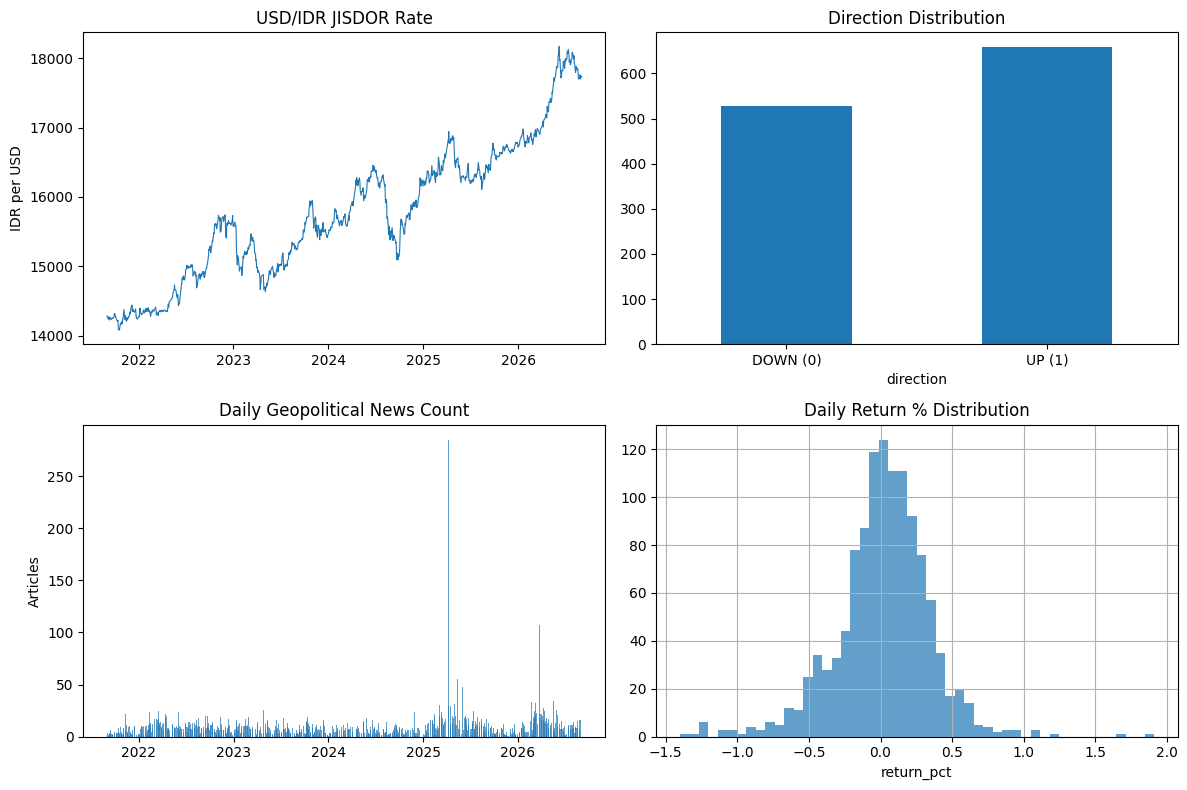

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(daily['date'], daily['jisdor'], linewidth=0.8)
axes[0, 0].set_title('USD/IDR JISDOR Rate')
axes[0, 0].set_ylabel('IDR per USD')

daily['direction'].value_counts().sort_index().plot.bar(ax=axes[0, 1])
axes[0, 1].set_title('Direction Distribution')
axes[0, 1].set_xticklabels(['DOWN (0)', 'UP (1)'], rotation=0)

axes[1, 0].bar(daily['date'], daily['news_count'], width=2, alpha=0.7)
axes[1, 0].set_title('Daily Geopolitical News Count')
axes[1, 0].set_ylabel('Articles')

daily['return_pct'].dropna().hist(bins=50, ax=axes[1, 1], alpha=0.7)
axes[1, 1].set_title('Daily Return % Distribution')
axes[1, 1].set_xlabel('return_pct')

plt.tight_layout()
plt.show()

## 6. Rate Lag Features

In [10]:
for lag in [1, 2, 3, 5]:
    daily[f'return_lag_{lag}'] = daily['return_pct'].shift(lag)
    daily[f'jisdor_lag_{lag}'] = daily['jisdor'].shift(lag)

daily['jisdor_ma_5'] = daily['jisdor'].rolling(5).mean()
daily['return_ma_5'] = daily['return_pct'].rolling(5).mean()

daily = daily.dropna(subset=['return_pct']).reset_index(drop=True)
print(f'After dropping missing return: {len(daily)} rows')

After dropping missing return: 1184 rows


## 7. Chronological Split (70/15/15)

Strict chronological split to prevent data leakage in time-series data.

In [11]:
n = len(daily)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = daily.iloc[:train_end].copy()
val = daily.iloc[train_end:val_end].copy()
test = daily.iloc[val_end:].copy()

print(f'train: {len(train)} rows  ({train["date"].iloc[0].date()} to {train["date"].iloc[-1].date()})')
print(f'val:   {len(val)} rows  ({val["date"].iloc[0].date()} to {val["date"].iloc[-1].date()})')
print(f'test:  {len(test)} rows  ({test["date"].iloc[0].date()} to {test["date"].iloc[-1].date()})')

# save splits
os.makedirs('data/splits', exist_ok=True)
train.to_csv('data/splits/train.csv', index=False)
val.to_csv('data/splits/val.csv', index=False)
test.to_csv('data/splits/test.csv', index=False)
print('\nSplits saved to data/splits/')

train: 828 rows  (2021-09-02 to 2025-02-20)
val:   178 rows  (2025-02-21 to 2025-11-21)
test:  178 rows  (2025-11-24 to 2026-09-01)

Splits saved to data/splits/


## 8. Naive Baselines

In [12]:
y_train = train['direction']
y_test = test['direction']

# Majority class
majority = y_train.mode()[0]
pred_majority = np.full(len(y_test), majority)

# Persistence (predict = yesterday's direction)
pred_persist = daily['direction'].shift(1).iloc[val_end:].values
persist_valid = ~np.isnan(pred_persist)

print('=== Majority Class Baseline ===')
print(f'Always predicts: {majority}')
print(f'Accuracy:  {accuracy_score(y_test, pred_majority):.4f}')
print(f'F1 macro:  {f1_score(y_test, pred_majority, average="macro"):.4f}')

print('\n=== Persistence Baseline ===')
print(f'Accuracy:  {accuracy_score(y_test[persist_valid], pred_persist[persist_valid]):.4f}')
print(f'F1 macro:  {f1_score(y_test[persist_valid], pred_persist[persist_valid], average="macro"):.4f}')

=== Majority Class Baseline ===
Always predicts: 1
Accuracy:  0.5843
F1 macro:  0.3688

=== Persistence Baseline ===
Accuracy:  0.5506
F1 macro:  0.5374


## 9. Combined Model — Logistic Regression

Uses both historical rate lag features and the NLP features (TF-IDF intensity + Loughran-McDonald sentiment per geopolitical category).

In [13]:
nlp_cols = [
    'news_count',
    'armed_conflict_tfidf_intensity', 'armed_conflict_lm_tone', 'armed_conflict_count',
    'sanctions_tfidf_intensity', 'sanctions_lm_tone', 'sanctions_count',
    'trade_conflict_tfidf_intensity', 'trade_conflict_lm_tone', 'trade_conflict_count',
    'energy_geopolitics_tfidf_intensity', 'energy_geopolitics_lm_tone', 'energy_geopolitics_count',
    'political_instability_tfidf_intensity', 'political_instability_lm_tone', 'political_instability_count',
    'monetary_geoeconomic_tfidf_intensity', 'monetary_geoeconomic_lm_tone', 'monetary_geoeconomic_count',
]

rate_cols = [c for c in daily.columns if c.startswith(('return_lag', 'jisdor_lag', 'jisdor_ma', 'return_ma'))]
feature_cols = rate_cols + [c for c in nlp_cols if c in daily.columns]

print(f'Total features: {len(feature_cols)}')
print(f'  Rate features: {len(rate_cols)}')
print(f'  NLP features:  {len(feature_cols) - len(rate_cols)}')

Total features: 29
  Rate features: 10
  NLP features:  19


In [14]:
X_train = train[feature_cols].fillna(0)
X_val = val[feature_cols].fillna(0)
X_test = test[feature_cols].fillna(0)
y_val = val['direction']

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)

pred_val = model.predict(X_val_s)
pred_test = model.predict(X_test_s)

print('=== Validation ===')
print(f'Accuracy:  {accuracy_score(y_val, pred_val):.4f}')
print(f'F1 macro:  {f1_score(y_val, pred_val, average="macro"):.4f}')

print('\n=== Test ===')
print(f'Accuracy:  {accuracy_score(y_test, pred_test):.4f}')
print(f'F1 macro:  {f1_score(y_test, pred_test, average="macro"):.4f}')

print('\nClassification Report (Test):')
print(classification_report(y_test, pred_test, target_names=['DOWN (0)', 'UP (1)']))

=== Validation ===
Accuracy:  0.7079
F1 macro:  0.7077

=== Test ===
Accuracy:  0.7472
F1 macro:  0.7370

Classification Report (Test):
              precision    recall  f1-score   support

    DOWN (0)       0.71      0.66      0.69        74
      UP (1)       0.77      0.81      0.79       104

    accuracy                           0.75       178
   macro avg       0.74      0.73      0.74       178
weighted avg       0.75      0.75      0.75       178



## 10. Confusion Matrix

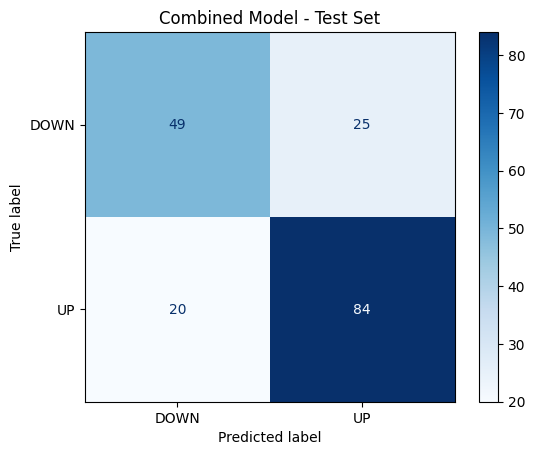

In [15]:
cm = confusion_matrix(y_test, pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=['DOWN', 'UP'])
disp.plot(cmap='Blues')
plt.title('Combined Model - Test Set')
plt.show()

## 11. Results Comparison

In [16]:
results = pd.DataFrame({
    'Model': ['Majority Class', 'Persistence', 'Combined LR (rate + NLP)'],
    'Accuracy': [
        accuracy_score(y_test, pred_majority),
        accuracy_score(y_test[persist_valid], pred_persist[persist_valid]),
        accuracy_score(y_test, pred_test),
    ],
    'F1 Macro': [
        f1_score(y_test, pred_majority, average='macro'),
        f1_score(y_test[persist_valid], pred_persist[persist_valid], average='macro'),
        f1_score(y_test, pred_test, average='macro'),
    ],
}).round(4)

print(results.to_string(index=False))

                   Model  Accuracy  F1 Macro
          Majority Class    0.5843    0.3688
             Persistence    0.5506    0.5374
Combined LR (rate + NLP)    0.7472    0.7370


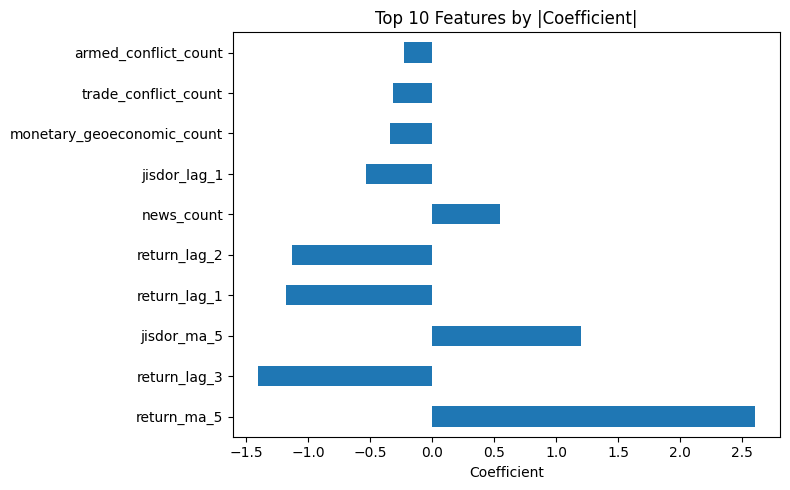

In [17]:
# top features
coefs = pd.Series(model.coef_[0], index=feature_cols).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
coefs.head(10).plot.barh(ax=ax)
ax.set_title('Top 10 Features by |Coefficient|')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()